# Gaussian Mixture Models using Expectation-Maximization (EM)

---

## 1. Introduction

### 1.1 Clustering and the Limitations of K-Means

Clustering is the task of grouping unlabeled data points into subsets (clusters) such that points within a cluster are more similar to each other than to points in other clusters.

**K-Means** is the most common clustering algorithm. It assigns each point to exactly one cluster and minimizes within-cluster sum of squared distances. However, K-Means has notable limitations:

1. **Hard assignments.** Each point belongs to exactly one cluster. This is inappropriate when cluster boundaries are ambiguous or data points could plausibly belong to multiple clusters.
2. **Spherical clusters only.** K-Means implicitly assumes clusters are roughly spherical with equal radius. It performs poorly on elongated or differently-scaled clusters.
3. **No uncertainty quantification.** K-Means gives no sense of how confident an assignment is.

### 1.2 Probabilistic Clustering

A more principled approach frames clustering as **density estimation** under a mixture model. Each cluster is represented by a probability distribution, and each data point is assigned a probability of belonging to each cluster — a **soft assignment**.

This yields richer information: a point near the boundary of two clusters will have high probability for both, rather than an arbitrary hard assignment.

**Gaussian Mixture Models (GMMs)** are the canonical example. They assume the data is generated from a weighted combination of Gaussian distributions. Fitting a GMM is done via the **Expectation-Maximization (EM)** algorithm.

---
## 2. The Multivariate Gaussian Distribution

A $d$-dimensional random variable $\mathbf{x}$ follows a multivariate Gaussian distribution with mean $\boldsymbol{\mu} \in \mathbb{R}^d$ and covariance matrix $\boldsymbol{\Sigma} \in \mathbb{R}^{d \times d}$ if its probability density function is:

$$
\mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{d/2} |\boldsymbol{\Sigma}|^{1/2}}
\exp\!\left(-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})\right)
$$

**Interpretation:**
- $\boldsymbol{\mu}$: The center (mean) of the distribution — the point of highest density.
- $\boldsymbol{\Sigma}$: Controls the shape and orientation of the density contours.
  - Diagonal $\boldsymbol{\Sigma}$: Axis-aligned ellipsoids.
  - Full $\boldsymbol{\Sigma}$: Rotated ellipsoids.
  - $\boldsymbol{\Sigma} = \sigma^2 I$: Spherical (isotropic) clusters as in K-Means.

---
## 3. Gaussian Mixture Models

### 3.1 Definition

A Gaussian Mixture Model with $K$ components defines the following generative process for a data point $\mathbf{x}$:

1. Sample a component index: $z \sim \text{Categorical}(\pi_1, \ldots, \pi_K)$
2. Sample the observation: $\mathbf{x} \mid z = k \sim \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$

The marginal density of $\mathbf{x}$ is:

$$
p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)
$$

where:
- $\pi_k \geq 0$ are the **mixing weights**, with $\sum_k \pi_k = 1$.
- $\boldsymbol{\mu}_k$ is the mean of component $k$.
- $\boldsymbol{\Sigma}_k$ is the covariance matrix of component $k$.

### 3.2 Latent Variables

The component index $z$ is a **latent variable** — it is not observed in the data. If we knew which component generated each point, parameter estimation would be straightforward. The challenge of fitting a GMM is that these assignments are hidden, which motivates the EM algorithm.

---
## 4. The Expectation-Maximization Algorithm

### 4.1 Objective: Maximum Likelihood Estimation

Given observed data $\{\mathbf{x}_1, \ldots, \mathbf{x}_n\}$, we want to find parameters $\theta = \{\pi_k, \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k\}_{k=1}^K$ that maximize the log-likelihood:

$$
\ell(\theta) = \sum_{i=1}^{n} \log \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)
$$

The $\log \sum$ structure makes direct optimization difficult. EM works around this by iteratively maximizing a lower bound.

### 4.2 E-Step: Compute Responsibilities

Given current parameters $\theta^{(t)}$, compute the **posterior probability** (responsibility) that component $k$ generated point $\mathbf{x}_i$:

$$
r_{ik} = p(z_i = k \mid \mathbf{x}_i, \theta^{(t)}) = \frac{\pi_k^{(t)} \, \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_k^{(t)}, \boldsymbol{\Sigma}_k^{(t)})}{\sum_{j=1}^{K} \pi_j^{(t)} \, \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_j^{(t)}, \boldsymbol{\Sigma}_j^{(t)})}
$$

$r_{ik} \in [0,1]$ and $\sum_k r_{ik} = 1$ for each $i$.

### 4.3 M-Step: Update Parameters

Using the responsibilities as soft weights, update each parameter by maximizing the expected complete-data log-likelihood:

$$
N_k = \sum_{i=1}^{n} r_{ik} \qquad \text{(effective count of points in cluster } k\text{)}
$$

$$
\boldsymbol{\mu}_k^{\text{new}} = \frac{1}{N_k} \sum_{i=1}^{n} r_{ik} \, \mathbf{x}_i
$$

$$
\boldsymbol{\Sigma}_k^{\text{new}} = \frac{1}{N_k} \sum_{i=1}^{n} r_{ik} \, (\mathbf{x}_i - \boldsymbol{\mu}_k^{\text{new}})(\mathbf{x}_i - \boldsymbol{\mu}_k^{\text{new}})^\top
$$

$$
\pi_k^{\text{new}} = \frac{N_k}{n}
$$

### 4.4 Convergence

EM is guaranteed to increase (or maintain) the log-likelihood at each iteration. The algorithm terminates when the change in log-likelihood drops below a tolerance threshold, or when a maximum number of iterations is reached.

---
## 5. Implementation From Scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse

np.random.seed(42)
print("NumPy version:", np.__version__)

NumPy version: 2.0.2


In [2]:
def multivariate_gaussian_pdf(X, mean, cov):
    """
    Evaluate the multivariate Gaussian PDF for each row of X.

    Numerically stable: uses log-space computation internally
    to avoid underflow with high-dimensional or small-covariance distributions.

    Parameters
    ----------
    X    : ndarray (n_samples, d)
    mean : ndarray (d,)
    cov  : ndarray (d, d)

    Returns
    -------
    pdf  : ndarray (n_samples,) — density at each point
    """
    d = X.shape[1]
    diff = X - mean                         # (n, d)

    # Regularize covariance to ensure positive definiteness
    cov_reg = cov + 1e-6 * np.eye(d)

    # Cholesky decomposition for stable inversion and determinant
    try:
        L = np.linalg.cholesky(cov_reg)     # lower triangular
    except np.linalg.LinAlgError:
        # Fallback: add stronger regularization if Cholesky fails
        cov_reg = cov + 1e-4 * np.eye(d)
        L = np.linalg.cholesky(cov_reg)

    # Solve L @ y = diff.T  =>  y = L^{-1} diff.T
    # Mahalanobis^2 = diff @ Sigma^{-1} @ diff.T = ||y||^2
    y = np.linalg.solve(L, diff.T)          # (d, n)
    mahal_sq = np.sum(y ** 2, axis=0)       # (n,)

    # log det(Sigma) = 2 * sum(log(diag(L)))
    log_det = 2.0 * np.sum(np.log(np.diag(L)))

    log_pdf = -0.5 * (d * np.log(2 * np.pi) + log_det + mahal_sq)
    return np.exp(log_pdf)


def initialize_parameters(X, K):
    """
    Initialize GMM parameters using K-Means++ style seeding for means,
    identity matrices for covariances, and uniform weights.

    Parameters
    ----------
    X : ndarray (n_samples, d)
    K : int, number of components

    Returns
    -------
    means  : ndarray (K, d)
    covs   : list of K ndarrays (d, d)
    weights: ndarray (K,)
    """
    n, d = X.shape

    # K-Means++ initialization for means
    idx = np.random.randint(0, n)
    means = [X[idx].copy()]

    for _ in range(K - 1):
        # Distance from each point to the nearest chosen mean
        dists = np.array([
            min(np.sum((x - m) ** 2) for m in means)
            for x in X
        ])
        probs = dists / dists.sum()
        idx = np.random.choice(n, p=probs)
        means.append(X[idx].copy())

    means = np.array(means)                             # (K, d)
    covs = [np.eye(d) for _ in range(K)]               # identity covariances
    weights = np.ones(K) / K                            # uniform weights

    return means, covs, weights


def e_step(X, means, covs, weights):
    """
    Compute responsibilities r[i, k] = p(z_i = k | x_i, theta).

    Parameters
    ----------
    X       : ndarray (n, d)
    means   : ndarray (K, d)
    covs    : list of K ndarrays (d, d)
    weights : ndarray (K,)

    Returns
    -------
    R : ndarray (n, K) — responsibility matrix
    """
    K = len(weights)
    n = X.shape[0]
    R = np.zeros((n, K))

    for k in range(K):
        R[:, k] = weights[k] * multivariate_gaussian_pdf(X, means[k], covs[k])

    # Normalize: sum over k equals 1 for each sample i
    row_sums = R.sum(axis=1, keepdims=True)
    # Avoid division by zero (can occur in early iterations with poor init)
    row_sums = np.where(row_sums == 0, 1e-300, row_sums)
    R /= row_sums

    return R


def m_step(X, R):
    """
    Update GMM parameters given the responsibility matrix.

    Parameters
    ----------
    X : ndarray (n, d)
    R : ndarray (n, K)

    Returns
    -------
    means   : ndarray (K, d)
    covs    : list of K ndarrays (d, d)
    weights : ndarray (K,)
    """
    n, d = X.shape
    K = R.shape[1]

    # Effective cluster sizes
    Nk = R.sum(axis=0)    # (K,)

    # Update means
    means = (R.T @ X) / Nk[:, np.newaxis]    # (K, d)

    # Update covariances
    covs = []
    for k in range(K):
        diff = X - means[k]                  # (n, d)
        # Weighted outer products summed over all points
        cov_k = (R[:, k, np.newaxis] * diff).T @ diff / Nk[k]  # (d, d)
        covs.append(cov_k)

    # Update mixing weights
    weights = Nk / n

    return means, covs, weights


def log_likelihood(X, means, covs, weights):
    """
    Compute the log-likelihood of the data under the current GMM parameters.

    log L = sum_i log( sum_k pi_k * N(x_i | mu_k, Sigma_k) )

    Parameters
    ----------
    X       : ndarray (n, d)
    means   : ndarray (K, d)
    covs    : list of K ndarrays (d, d)
    weights : ndarray (K,)

    Returns
    -------
    float : log-likelihood value
    """
    K = len(weights)
    n = X.shape[0]
    densities = np.zeros((n, K))

    for k in range(K):
        densities[:, k] = weights[k] * multivariate_gaussian_pdf(X, means[k], covs[k])

    # Clamp to avoid log(0)
    mixture_density = densities.sum(axis=1)
    mixture_density = np.clip(mixture_density, 1e-300, None)

    return np.sum(np.log(mixture_density))


print("Functions defined.")

Functions defined.


In [3]:
class GaussianMixtureModel:
    """
    Gaussian Mixture Model fitted via the EM algorithm.

    Parameters
    ----------
    n_components : int
        Number of Gaussian components.
    max_iter     : int
        Maximum number of EM iterations.
    tol          : float
        Convergence threshold on log-likelihood change.
    """

    def __init__(self, n_components, max_iter=200, tol=1e-6):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol

        self.means_ = None
        self.covariances_ = None
        self.weights_ = None
        self.log_likelihoods_ = []
        self.n_iter_ = 0

    def fit(self, X):
        """
        Run the EM algorithm to fit the GMM to data X.

        Parameters
        ----------
        X : ndarray (n_samples, n_features)
        """
        # Initialize parameters
        means, covs, weights = initialize_parameters(X, self.n_components)
        self.log_likelihoods_ = []

        prev_ll = -np.inf

        for iteration in range(self.max_iter):
            # E-step
            R = e_step(X, means, covs, weights)

            # M-step
            means, covs, weights = m_step(X, R)

            # Evaluate log-likelihood
            ll = log_likelihood(X, means, covs, weights)
            self.log_likelihoods_.append(ll)

            # Check convergence
            if abs(ll - prev_ll) < self.tol:
                self.n_iter_ = iteration + 1
                break

            prev_ll = ll
        else:
            self.n_iter_ = self.max_iter

        self.means_ = means
        self.covariances_ = covs
        self.weights_ = weights

        return self

    def predict_proba(self, X):
        """Return soft (probabilistic) cluster assignments."""
        return e_step(X, self.means_, self.covariances_, self.weights_)

    def predict(self, X):
        """Return hard cluster labels (argmax of responsibilities)."""
        return np.argmax(self.predict_proba(X), axis=1)


print("GaussianMixtureModel class defined.")

GaussianMixtureModel class defined.


---
## 6. Visualization

### 6.1 Generate Synthetic Dataset

In [4]:
# Three well-separated Gaussian clusters with different shapes
true_means = np.array([
    [0.0,  0.0],
    [5.0,  1.0],
    [2.0,  5.0]
])

true_covs = [
    np.array([[1.0, 0.7], [0.7, 0.8]]),   # elongated
    np.array([[0.5, 0.0], [0.0, 1.5]]),   # axis-aligned
    np.array([[1.2, -0.6], [-0.6, 0.8]])  # negative correlation
]

true_weights = np.array([0.4, 0.35, 0.25])
n_samples = 400
K = 3

# Sample from the mixture
cluster_sizes = np.random.multinomial(n_samples, true_weights)
X_parts = [
    np.random.multivariate_normal(true_means[k], true_covs[k], cluster_sizes[k])
    for k in range(K)
]
true_labels = np.concatenate([np.full(cluster_sizes[k], k) for k in range(K)])
X_data = np.vstack(X_parts)

# Shuffle
perm = np.random.permutation(n_samples)
X_data = X_data[perm]
true_labels = true_labels[perm]

print(f"Dataset shape: {X_data.shape}")
print(f"Cluster sizes: {cluster_sizes}")

Dataset shape: (400, 2)
Cluster sizes: [154 142 104]


### 6.2 Fit the GMM

In [5]:
gmm = GaussianMixtureModel(n_components=K, max_iter=300, tol=1e-8)
gmm.fit(X_data)

labels_pred = gmm.predict(X_data)

print(f"Converged in {gmm.n_iter_} iterations.")
print(f"Final log-likelihood: {gmm.log_likelihoods_[-1]:.4f}")
print()
print("Estimated means:")
for k in range(K):
    print(f"  Component {k}: {gmm.means_[k].round(3)}")
print()
print("Estimated weights:", gmm.weights_.round(3))

Converged in 13 iterations.
Final log-likelihood: -1403.6046

Estimated means:
  Component 0: [-0.004  0.013]
  Component 1: [4.937 1.046]
  Component 2: [2.055 5.009]

Estimated weights: [0.383 0.362 0.255]


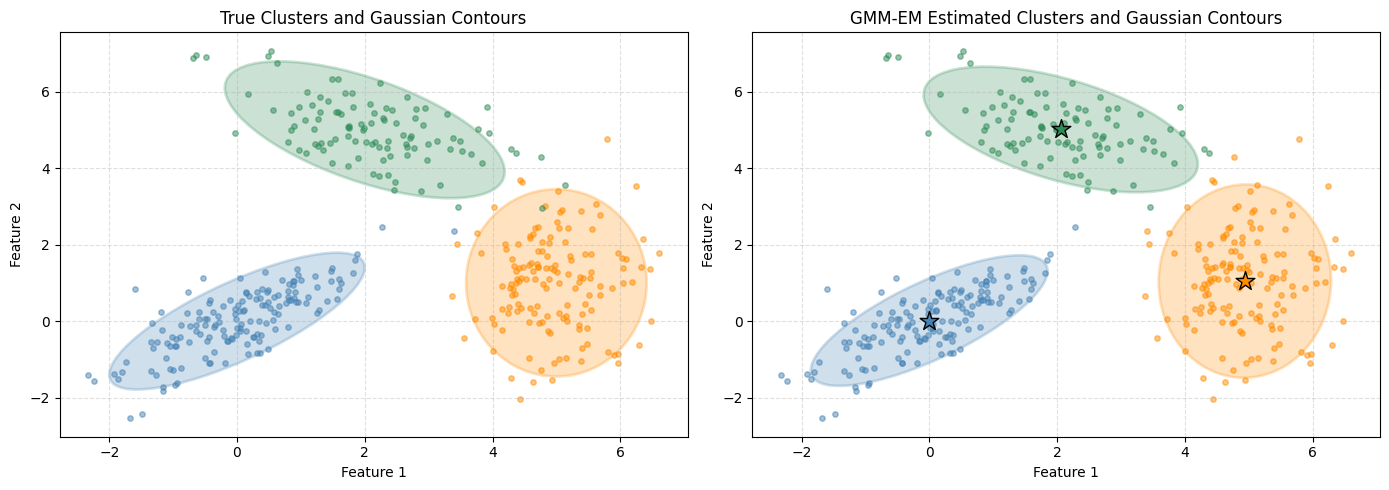

In [6]:
def draw_ellipse(ax, mean, cov, color, alpha=0.25, n_std=2.0):
    """
    Draw a confidence ellipse for a 2D Gaussian.

    The ellipse corresponds to `n_std` standard deviations from the mean.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # Ensure eigenvalues are positive
    eigenvalues = np.maximum(eigenvalues, 1e-8)

    # Angle of the major axis
    angle = np.degrees(np.arctan2(eigenvectors[1, 1], eigenvectors[0, 1]))

    # Width and height of the ellipse at n_std standard deviations
    width  = 2 * n_std * np.sqrt(eigenvalues[1])
    height = 2 * n_std * np.sqrt(eigenvalues[0])

    ell = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        facecolor=color,
        alpha=alpha,
        edgecolor=color,
        linewidth=2
    )
    ax.add_patch(ell)


COLORS = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True clusters
ax = axes[0]
for k in range(K):
    mask = true_labels == k
    ax.scatter(X_data[mask, 0], X_data[mask, 1], s=15, alpha=0.5, color=COLORS[k])
    draw_ellipse(ax, true_means[k], true_covs[k], color=COLORS[k])
ax.set_title('True Clusters and Gaussian Contours')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, linestyle='--', alpha=0.4)

# Estimated clusters
ax = axes[1]
for k in range(K):
    mask = labels_pred == k
    ax.scatter(X_data[mask, 0], X_data[mask, 1], s=15, alpha=0.5, color=COLORS[k])
    draw_ellipse(ax, gmm.means_[k], gmm.covariances_[k], color=COLORS[k])
    ax.scatter(*gmm.means_[k], marker='*', s=200, color=COLORS[k], edgecolor='black', zorder=5)
ax.set_title('GMM-EM Estimated Clusters and Gaussian Contours')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 6.3 Convergence of Log-Likelihood

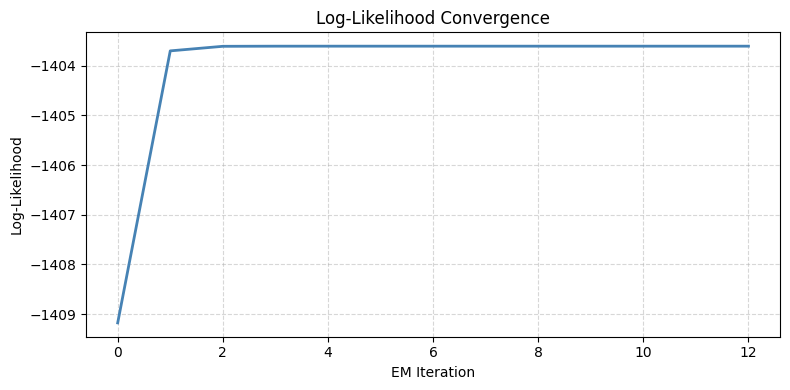

Total improvement: 5.57


In [7]:
plt.figure(figsize=(8, 4))
plt.plot(gmm.log_likelihoods_, color='steelblue', lw=2)
plt.xlabel('EM Iteration')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood Convergence')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Total improvement: {gmm.log_likelihoods_[-1] - gmm.log_likelihoods_[0]:.2f}")

### 6.4 Soft Assignments

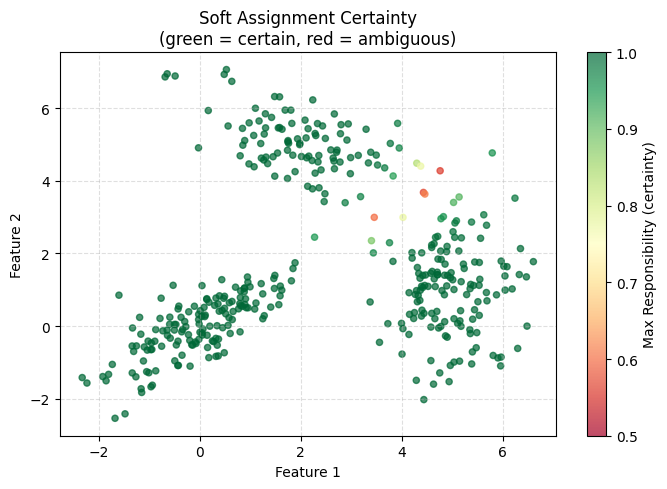

Points with max responsibility < 0.80: 6 (1.5%)


In [8]:
# Visualize the uncertainty in cluster assignments
proba = gmm.predict_proba(X_data)   # (n, K)

# Use max responsibility as a measure of assignment certainty
max_resp = proba.max(axis=1)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X_data[:, 0], X_data[:, 1],
    c=max_resp, cmap='RdYlGn',
    s=20, alpha=0.7, vmin=0.5, vmax=1.0
)
plt.colorbar(scatter, label='Max Responsibility (certainty)')
plt.title('Soft Assignment Certainty\n(green = certain, red = ambiguous)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

uncertain = (max_resp < 0.8).sum()
print(f"Points with max responsibility < 0.80: {uncertain} ({uncertain/n_samples*100:.1f}%)")

---
## 7. Comparison with scikit-learn

In [9]:
from sklearn.mixture import GaussianMixture

# Fit sklearn GMM with the same number of components
gmm_sk = GaussianMixture(
    n_components=K,
    covariance_type='full',
    max_iter=300,
    tol=1e-8,
    random_state=42
)
gmm_sk.fit(X_data)
labels_sk = gmm_sk.predict(X_data)

print("=== Our Implementation ===")
print("Log-likelihood:", gmm.log_likelihoods_[-1])
print("Weights:", np.sort(gmm.weights_).round(4))

print("\n=== scikit-learn ===")
# sklearn reports the per-sample average log-likelihood via score()
sk_ll = gmm_sk.score(X_data) * n_samples
print("Log-likelihood:", round(sk_ll, 4))
print("Weights:", np.sort(gmm_sk.weights_).round(4))

print(f"\nLog-likelihood difference: {abs(gmm.log_likelihoods_[-1] - sk_ll):.4f}")

=== Our Implementation ===
Log-likelihood: -1403.6045623181758
Weights: [0.2552 0.3621 0.3826]

=== scikit-learn ===
Log-likelihood: -1403.6046
Weights: [0.2552 0.3621 0.3826]

Log-likelihood difference: 0.0000


In [10]:
# Compare cluster assignments (note: label permutation may differ)
from itertools import permutations

def assignment_accuracy(labels_true, labels_pred, K):
    """Find the label permutation that maximizes agreement with ground truth."""
    best = 0
    for perm in permutations(range(K)):
        mapped = np.array([perm[l] for l in labels_pred])
        acc = (mapped == labels_true).mean()
        if acc > best:
            best = acc
    return best

acc_scratch = assignment_accuracy(true_labels, labels_pred, K)
acc_sklearn = assignment_accuracy(true_labels, labels_sk, K)

print(f"Clustering accuracy (from scratch): {acc_scratch*100:.1f}%")
print(f"Clustering accuracy (scikit-learn): {acc_sklearn*100:.1f}%")

Clustering accuracy (from scratch): 99.0%
Clustering accuracy (scikit-learn): 99.0%


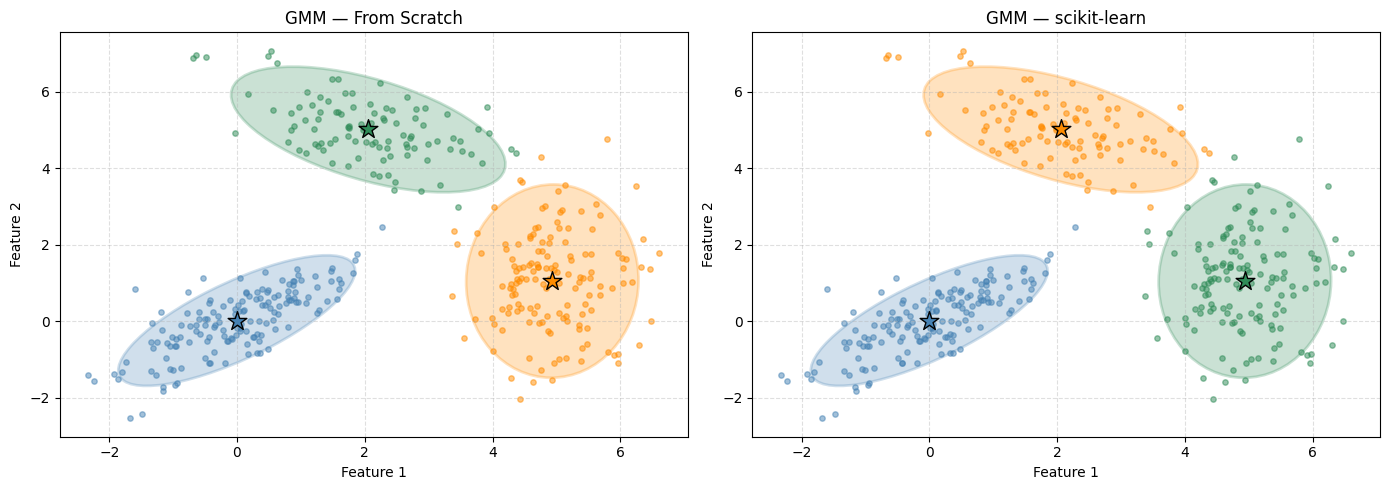

In [11]:
# Visual side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, means, covs, title in [
    (axes[0], labels_pred, gmm.means_, gmm.covariances_,  'From Scratch'),
    (axes[1], labels_sk,  gmm_sk.means_, list(gmm_sk.covariances_), 'scikit-learn')
]:
    for k in range(K):
        mask = labels == k
        ax.scatter(X_data[mask, 0], X_data[mask, 1], s=15, alpha=0.5, color=COLORS[k])
        draw_ellipse(ax, means[k], covs[k], color=COLORS[k])
        ax.scatter(*means[k], marker='*', s=200, color=COLORS[k], edgecolor='black', zorder=5)
    ax.set_title(f'GMM — {title}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## 8. Analysis

### 8.1 GMMs vs K-Means

**Advantages of GMMs over K-Means:**

1. **Soft assignments.** GMMs assign a probability to each cluster, quantifying uncertainty near cluster boundaries. K-Means hard assignments can be misleading when data is overlapping.

2. **Flexible cluster shapes.** With full covariance matrices, GMMs can capture elongated, rotated, and differently-scaled clusters. K-Means implicitly assumes spherical clusters.

3. **Principled probabilistic model.** GMMs provide a proper generative model of the data, enabling tasks like density estimation, anomaly detection, and Bayesian inference.

4. **Richer cluster characterization.** Each cluster is described by a mean, covariance, and weight — far more information than a centroid alone.

### 8.2 Limitations of GMMs

1. **Number of components $K$ must be specified.** Like K-Means, GMMs require $K$ to be set by the user. Model selection via BIC/AIC can help but adds overhead.

2. **Local optima.** EM is guaranteed to converge to a local maximum of the likelihood. The result depends on initialization; multiple random restarts are typically used in practice.

3. **Degenerate solutions.** If a Gaussian collapses onto a single data point, its covariance becomes singular and the likelihood diverges. Regularization (adding $\epsilon I$ to $\Sigma$) is necessary.

4. **Computational cost.** Fitting GMMs scales as $O(n K d^2)$ per iteration due to covariance matrix operations. For large $d$, diagonal or tied covariance constraints are commonly used.

5. **Gaussian assumption.** If the true clusters are not approximately Gaussian (e.g., ring-shaped, crescent-shaped), GMMs may produce poor results regardless of $K$.

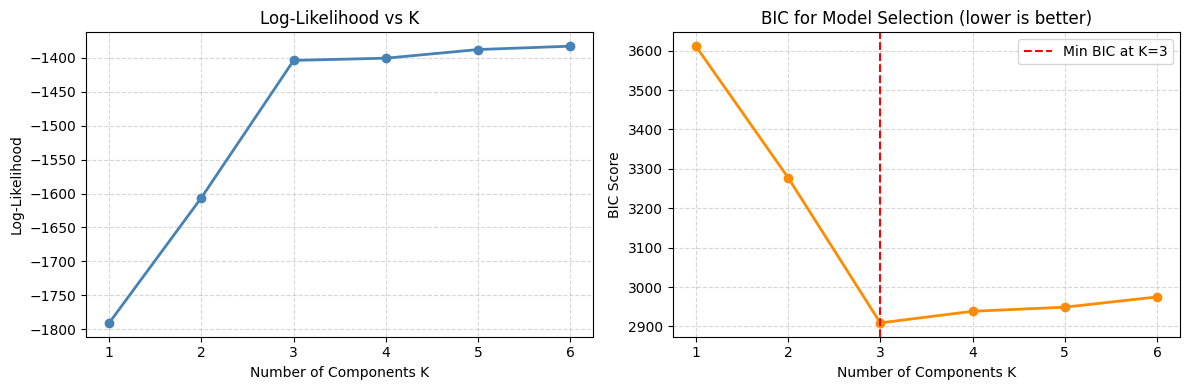

BIC-selected number of components: K = 3 (true K = 3)


In [12]:
# Model selection: BIC-style criterion using log-likelihood and parameter count
# Number of free parameters for a K-component GMM in d dimensions with full covariances:
# K * d (means) + K * d*(d+1)/2 (unique cov entries) + (K-1) (weights) parameters

d = X_data.shape[1]
n = X_data.shape[0]

def bic(log_ll, K, n, d):
    n_params = K * d + K * d * (d + 1) // 2 + (K - 1)
    return -2 * log_ll + n_params * np.log(n)

k_range = range(1, 7)
bic_scores = []
ll_scores = []

for k in k_range:
    g = GaussianMixtureModel(n_components=k, max_iter=200, tol=1e-7)
    g.fit(X_data)
    ll = g.log_likelihoods_[-1]
    ll_scores.append(ll)
    bic_scores.append(bic(ll, k, n, d))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, ll_scores, 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('Number of Components K')
axes[0].set_ylabel('Log-Likelihood')
axes[0].set_title('Log-Likelihood vs K')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(k_range, bic_scores, 'o-', color='darkorange', lw=2)
axes[1].axvline(np.argmin(bic_scores) + 1, color='red', linestyle='--', lw=1.5, label=f'Min BIC at K={np.argmin(bic_scores)+1}')
axes[1].set_xlabel('Number of Components K')
axes[1].set_ylabel('BIC Score')
axes[1].set_title('BIC for Model Selection (lower is better)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

best_k = np.argmin(bic_scores) + 1
print(f"BIC-selected number of components: K = {best_k} (true K = {K})")

---
## 9. Conclusion

This notebook built a complete Gaussian Mixture Model from scratch using the EM algorithm.

Key takeaways:

- GMMs model data as a weighted sum of Gaussian densities, where each Gaussian represents a cluster. The latent variable $z$ indicates the cluster assignment.
- EM alternates between computing soft cluster assignments (E-step) and updating parameters to maximize expected log-likelihood (M-step). The log-likelihood is guaranteed to be non-decreasing.
- Numerical stability requires regularizing covariance matrices (adding $\epsilon I$) and using Cholesky decomposition for efficient and stable Mahalanobis distance computation.
- Our implementation matches scikit-learn in terms of log-likelihood and cluster quality on the synthetic dataset.
- BIC provides a practical model selection criterion that penalizes model complexity, often recovering the true number of components.
- GMMs generalize K-Means: with spherical covariances ($\Sigma_k = \sigma^2 I$) and hard assignments (responsibilities approaching 0 or 1), GMM-EM converges to the same solution as K-Means.